# Load Libs

In [1]:
#Homemade Functions
from functions.functions_analysis import *
from functions.Path_combine_function import *
from functions.plot_functions import *
from functions.Preproc_functions import *

#More nifti packages
from nilearn import plotting
import nibabel as nib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Dipy
import dipy as dp
from dipy.io.image import load_nifti, save_nifti
from dipy.io import read_bvals_bvecs
from dipy.core.gradients import gradient_table
import dipy.data as dpd

#Preproc
from dipy.align import motion_correction
import dipy.direction.peaks as dpp
from dipy.viz import window, actor
from dipy.segment.mask import median_otsu
from dipy.core.histeq import histeq

from dipy.denoise.nlmeans import nlmeans
from dipy.denoise.noise_estimate import estimate_sigma

#DIPY Plot
from dipy.viz import window, actor
from dipy.data import get_sphere

#Regular Packages
import keyboard  # For detecting keypresses
import IPython

from matplotlib.colors import ListedColormap
import numpy as np
import os
import ants

from pathlib import Path
from time import time
import time  # For simulating work
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider




import matplotlib.patches as mpatches

segment_info = {
    "C1":  {"pct": 1.6, "cum_pct": 1.6},
    "C2":  {"pct": 2.2, "cum_pct": 3.9},
    "C3":  {"pct": 3.5, "cum_pct": 7.3},
    "C4":  {"pct": 3.5, "cum_pct": 10.8},
    "C5":  {"pct": 3.5, "cum_pct": 14.3},
    "C6":  {"pct": 3.3, "cum_pct": 17.6},
    "C7":  {"pct": 3.2, "cum_pct": 20.8},
    "C8":  {"pct": 3.4, "cum_pct": 24.1},
    "T1":  {"pct": 3.6, "cum_pct": 27.7},
    "T2":  {"pct": 3.9, "cum_pct": 31.6},
    "T3":  {"pct": 4.4, "cum_pct": 36.0},
    "T4":  {"pct": 5.0, "cum_pct": 41.0},
    "T5":  {"pct": 5.1, "cum_pct": 46.1},
    "T6":  {"pct": 5.6, "cum_pct": 51.8},
    "T7":  {"pct": 5.6, "cum_pct": 57.4},
    "T8":  {"pct": 5.4, "cum_pct": 62.7},
    "T9":  {"pct": 5.1, "cum_pct": 67.8},
    "T10": {"pct": 4.7, "cum_pct": 72.4},
    "T11": {"pct": 4.3, "cum_pct": 76.7},
    "T12": {"pct": 3.9, "cum_pct": 80.6},
    "L1":  {"pct": 3.6, "cum_pct": 84.2},
    "L2":  {"pct": 2.8, "cum_pct": 87.0},
    "L3":  {"pct": 2.4, "cum_pct": 89.4},
    "L4":  {"pct": 2.2, "cum_pct": 91.6},
    "L5":  {"pct": 1.7, "cum_pct": 93.3},
    "S1":  {"pct": 1.5, "cum_pct": 94.9},
    "S2":  {"pct": 1.6, "cum_pct": 96.4},
    "S3":  {"pct": 1.4, "cum_pct": 97.8},
    "S4":  {"pct": 1.3, "cum_pct": 99.1},
    "S5":  {"pct": 0.9, "cum_pct": 100.0},
}
segment_cum_pct = {
    "C1": 1.6, "C2": 3.9, "C3": 7.3, "C4": 10.8, "C5": 14.3, "C6": 17.6, "C7": 20.8, "C8": 24.1,
    "T1": 27.7, "T2": 31.6, "T3": 36.0, "T4": 41.0, "T5": 46.1, "T6": 51.8, "T7": 57.4, "T8": 62.7,
    "T9": 67.8, "T10": 72.4, "T11": 76.7, "T12": 80.6,
    "L1": 84.2, "L2": 87.0, "L3": 89.4, "L4": 91.6, "L5": 93.3,
    "S1": 94.9, "S2": 96.4, "S3": 97.8, "S4": 99.1, "S5": 100.0,
}

min_z = 10
max_z = -150

#t2, affine_t2 = load_nifti("Combined_data/Rotated and Transposed/RARE_combined_trans_denoised_gibbs_masked_rotated_BFC_corrected20.nii.gz")
#t2 = t2[:,:,min_z:max_z]

t2_trans_in_b0_space, affine_t2_trans_in_b0_space  = load_nifti("Combined_Data/Transposed/T2_in_DWI.nii.gz")
t2_trans_in_b0_space = t2_trans_in_b0_space[:,:,min_z:max_z]

t2_trans, affine_t2_trans = load_nifti("Combined_Data/Transposed/RARE_combined_trans_denoised_gibbs_masked_BFC_corrected20.nii.gz")
t2_trans = t2_trans[:,:,min_z:max_z]


## Load GM Mask 
gm_wm_mask_path_trans = "Combined_Data/Transposed/Combined_GM_WM_mask_aug_FINAL_f1_threshold_dilated_96x96.npy" 
mask_gm_wm_trans = np.load(gm_wm_mask_path_trans).squeeze()
mask_gm_wm_trans = np.transpose(mask_gm_wm_trans, (2, 1, 0))
mask_gm_wm_trans = np.flip(mask_gm_wm_trans, axis=0)
mask_gm_wm_trans = mask_gm_wm_trans[:,:,min_z:max_z]


# Generate WM and GM masks from gm_wm_mask
mask_gm_trans = (mask_gm_wm_trans == 1).astype(bool)
mask_wm_trans = (mask_gm_wm_trans == 2).astype(bool)
mask_gm_wm_trans_final = np.where(mask_gm_wm_trans == 1, 1, np.where(mask_gm_wm_trans == 2, 1, 0)).astype(bool)


# Calculate actual z-index for all spinal segments using cum_pct and t2 z-dimension
z_dim = t2_trans.shape[2]
segment_z_index = {}

for seg, info in segment_info.items():
    cum_pct = info["cum_pct"]
    z_idx = int(round((cum_pct / 100) * (z_dim - 1)))
    segment_z_index[seg] = z_idx

print(segment_z_index)

rotation_data = np.load("Combined_data/complete_coordinates_of_lines_for_rotation.pkl", allow_pickle=True)
rotated_angles = rotation_data["smoothed_angle"][min_z:max_z]

{'C1': 29, 'C2': 70, 'C3': 132, 'C4': 195, 'C5': 258, 'C6': 318, 'C7': 375, 'C8': 435, 'T1': 500, 'T2': 570, 'T3': 649, 'T4': 740, 'T5': 832, 'T6': 934, 'T7': 1035, 'T8': 1131, 'T9': 1223, 'T10': 1306, 'T11': 1384, 'T12': 1454, 'L1': 1519, 'L2': 1569, 'L3': 1613, 'L4': 1652, 'L5': 1683, 'S1': 1712, 'S2': 1739, 'S3': 1764, 'S4': 1788, 'S5': 1804}


# Figure 2.0 A

In [50]:
dti_fit = np.load("Results/tenfit_transposed_BFC20.npy", allow_pickle= True).item()
ODI_NODDI, affine = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_ODI.nii.gz")
ODI_NODDI = ODI_NODDI[:,:,10:-150]
def slice_mean_sem(vol, mask): 
    """vol: (X,Y,Z) metric; mask: (X,Y,Z) bool"""
    # zero-out non-GM; mark them NaN for nan-reductions
    arr_masked = np.where(mask, vol, np.nan)
    mean_z = np.nanmean(arr_masked, axis=(0,1))


    n      = np.sum(np.isfinite(arr_masked), axis=(0,1))
    mean_z = np.nanmean(arr_masked,          axis=(0,1))
    var_z  = np.nanvar(arr_masked,           axis=(0,1), ddof=1)  # sample variance
    sem_z  = np.sqrt(var_z) / np.sqrt(n)
    sem_z  = np.where(n > 1, sem_z, np.nan)  # guard small n

    return mean_z, sem_z


fa_corrected = dti_fit.fa
md_corrected = dti_fit.md
ad_corrected = dti_fit.ad
rd_corrected = dti_fit.rd

# All
fa_mean_corrected, fa_sem_corrected = slice_mean_sem(fa_corrected, mask = mask_gm_wm_trans)
md_mean_corrected, md_sem_corrected = slice_mean_sem(md_corrected, mask = mask_gm_wm_trans)
ad_mean_corrected, ad_sem_corrected = slice_mean_sem(ad_corrected, mask = mask_gm_wm_trans)
rd_mean_corrected, rd_sem_corrected = slice_mean_sem(rd_corrected, mask = mask_gm_wm_trans)
ODI_mean_corrected, ODI_sem_corrected = slice_mean_sem(ODI_NODDI, mask = mask_gm_wm_trans)

# GM
fa_mean_gm_corrected, fa_sem_gm_corrected = slice_mean_sem(fa_corrected, mask = mask_gm_trans)
md_mean_gm_corrected, md_sem_gm_corrected = slice_mean_sem(md_corrected, mask = mask_gm_trans)
ad_mean_gm_corrected, ad_sem_gm_corrected = slice_mean_sem(ad_corrected, mask = mask_gm_trans)
rd_mean_gm_corrected, rd_sem_gm_corrected = slice_mean_sem(rd_corrected, mask = mask_gm_trans)
ODI_mean_gm_corrected, ODI_sem_gm_corrected = slice_mean_sem(ODI_NODDI, mask = mask_gm_trans)

# WM
fa_mean_wm_corrected, fa_sem_wm_corrected = slice_mean_sem(fa_corrected, mask = mask_wm_trans)
md_mean_wm_corrected, md_sem_wm_corrected = slice_mean_sem(md_corrected, mask = mask_wm_trans)
ad_mean_wm_corrected, ad_sem_wm_corrected = slice_mean_sem(ad_corrected, mask = mask_wm_trans)
rd_mean_wm_corrected, rd_sem_wm_corrected = slice_mean_sem(rd_corrected, mask = mask_wm_trans)
ODI_mean_wm_corrected, ODI_sem_wm_corrected = slice_mean_sem(ODI_NODDI, mask = mask_wm_trans)



C:\Users\sigur\AppData\Local\Temp\ipykernel_72488\1631911858.py:8: RuntimeWarning: Mean of empty slice
  mean_z = np.nanmean(arr_masked, axis=(0,1))
C:\Users\sigur\AppData\Local\Temp\ipykernel_72488\1631911858.py:12: RuntimeWarning: Mean of empty slice
  mean_z = np.nanmean(arr_masked,          axis=(0,1))
C:\Users\sigur\AppData\Local\Temp\ipykernel_72488\1631911858.py:13: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_z  = np.nanvar(arr_masked,           axis=(0,1), ddof=1)  # sample variance


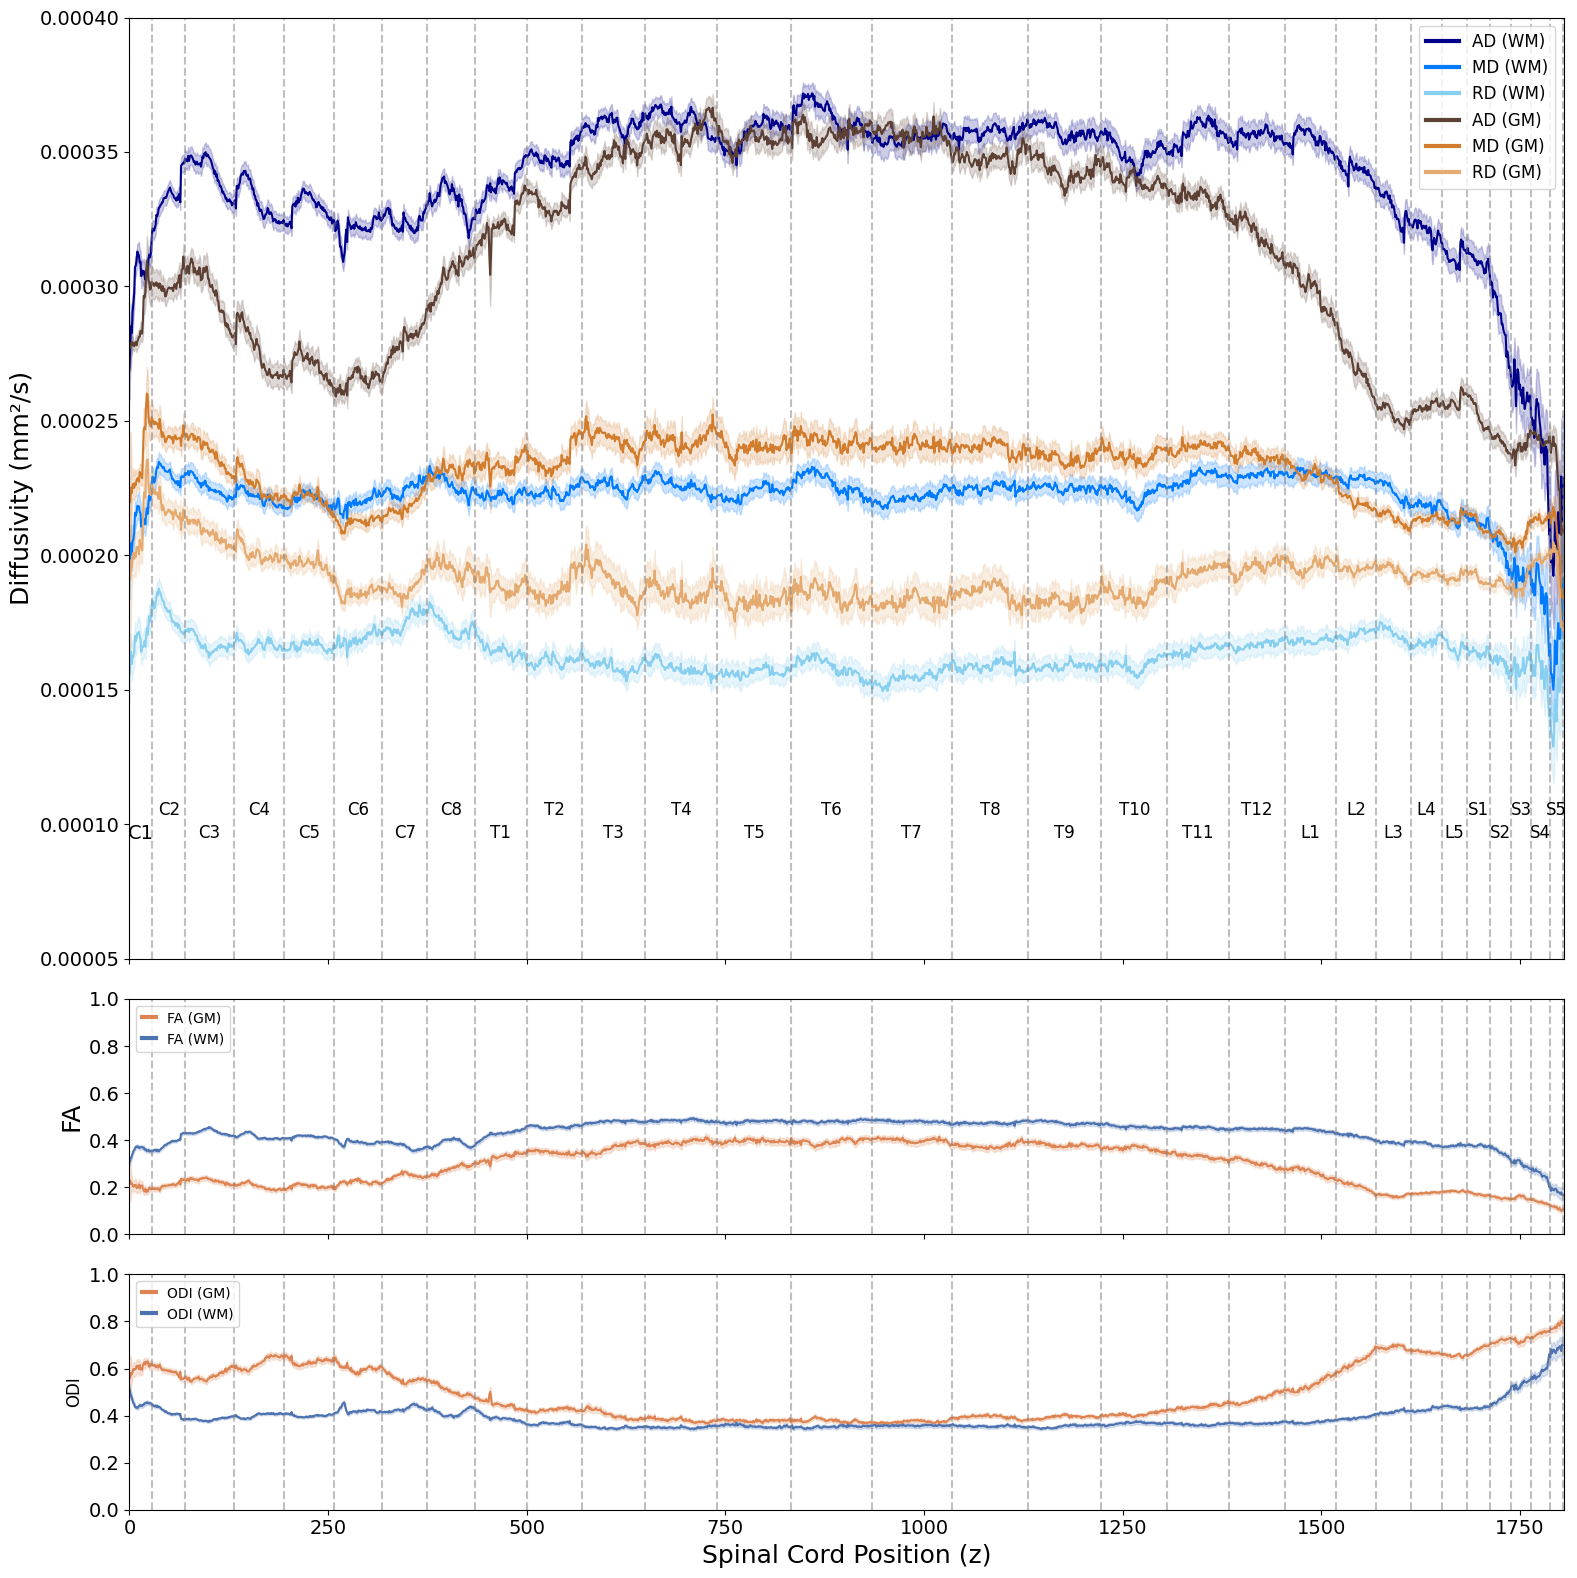

In [49]:
def plot_with_ci(mean, sem, label, color, ax, linestyle = "-"):
    z = np.arange(mean.shape[0])
    ci = 1.96 * sem
    ax.plot(z, mean, label=label, color=color, linestyle=linestyle)
    ax.fill_between(z, mean - ci, mean + ci, color=color, alpha=0.2)


################# Start of Plotting #################
fig, (ax, ax1, ax2) = plt.subplots(
    3, 1, figsize=(16, 16), sharex=True,
    gridspec_kw={'height_ratios': [4, 1, 1]}  # optional: bigger top plot
)

########################################
#########   TOP: MD / AD / RD   ########
########################################

plot_with_ci(md_mean_wm_corrected, md_sem_wm_corrected, 'MD (WM)',
             color=(0/255, 123/255, 255/255), ax=ax)
plot_with_ci(ad_mean_wm_corrected, ad_sem_wm_corrected, 'AD (WM)',
             color=(0/255, 0/255, 139/255), ax=ax)
plot_with_ci(rd_mean_wm_corrected, rd_sem_wm_corrected, 'RD (WM)',
             color=(137/255, 207/255, 240/255), ax=ax)

plot_with_ci(md_mean_gm_corrected, md_sem_gm_corrected, 'MD (GM)',
             color=(210/255, 125/255, 45/255), ax=ax)
plot_with_ci(ad_mean_gm_corrected, ad_sem_gm_corrected, 'AD (GM)',
             color=(92/255, 64/255, 51/255), ax=ax)
plot_with_ci(rd_mean_gm_corrected, rd_sem_gm_corrected, 'RD (GM)',
             color=(229/255, 170/255, 112/255), ax=ax)

# Reorder legend
handles, labels = ax.get_legend_handles_labels()
order = [1, 0, 2, 4, 3, 5]

leg = ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc='upper right'
)

# Thicker legend lines
for line in leg.get_lines():
    line.set_linewidth(3)

ax.set_ylim(0.00005, 0.0004)
ax.set_xlim(0, md_mean_wm_corrected.size)

########################################
#########      BOTTOM: FA      #########
########################################

plot_with_ci(fa_mean_gm_corrected, fa_sem_gm_corrected, 'FA (GM)',
             color=[0.867, 0.518, 0.322], ax=ax1)

plot_with_ci(fa_mean_wm_corrected, fa_sem_wm_corrected, 'FA (WM)',
             color=[0.298, 0.447, 0.690], ax=ax1, linestyle="-")

ax1.set_ylim(0, 1)

# Legend for FA
leg1 = ax1.legend(loc='upper left', handlelength=1, handleheight=1, fontsize = 10)
for line in leg1.get_lines():
    line.set_linewidth(3)


########################################
#########      BOTTOM: ODI     #########
########################################

plot_with_ci(ODI_mean_gm_corrected, ODI_sem_gm_corrected, 'ODI (GM)',
             color=[0.867, 0.518, 0.322], ax=ax2)

plot_with_ci(ODI_mean_wm_corrected, ODI_sem_wm_corrected, 'ODI (WM)',
             color=[0.298, 0.447, 0.690], ax=ax2, linestyle="-")

ax2.set_ylim(0, 1)
# Legend for ODI
leg2 = ax2.legend(loc='upper left', handlelength = 1, handleheight=1, fontsize = 10)
for line in leg2.get_lines():
    line.set_linewidth(3)

########################################
#########   SHARED X FEATURES   ########
########################################

# Vertical lines + segment labels (only draw once, on top axis)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

z_values = list(segment_z_index.values())

for i, (seg, z_idx) in enumerate(segment_z_index.items()):
    ax.axvline(x=z_idx, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=z_idx, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=z_idx, color='gray', linestyle='--', alpha=0.5)
    if i == 0:
        ax.text(z_idx/2, ax.get_ylim()[1]*0.25, seg,
                ha='center', va='top')
    else:
        x_mid = (z_idx - z_values[i-1]) / 2 + z_values[i-1]

        if i % 2 == 0:
            ax.text(x_mid, ax.get_ylim()[1]*0.25, seg,
                    ha='center', va='top', fontsize =12)
        else:
            ax.text(x_mid, ax.get_ylim()[1]*0.255, seg,
                    ha='center', va='bottom', fontsize =12)

########################################
#########   CLEANUP / LABELS   #########
########################################

ax.set_ylabel("Diffusivity (mm²/s)", fontsize = 18)
ax1.set_ylabel("FA", fontsize=18)

ax2.set_xlabel("Spinal Cord Position (z)", fontsize = 18)
ax2.set_ylabel("ODI", fontsize = 12)

for a in [ax, ax1, ax2]:
    a.tick_params(axis='both', labelsize=14)  # increase tick label size

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

plt.tight_layout()
path = "c:\\Users\\sigur\\OneDrive - University of Copenhagen\\Rune W. Berg's files - Sigurd Rune Shared folder\\Figure 2 (dwMRI Metrics)"
plt.savefig(path + "\\FA_ODI_MD_AD_RD_profiles.svg", dpi= 1000)
plt.show()

# Figure 2.0 B

In [1]:
plot_idx_dict ={"C4": 238,
 "T6": 945,
 "L2": 1560,
 "S3": 1742}

mask = np.load('Combined_Data/Transposed/Combined_GM_WM_mask_aug_FINAL_f1_threshold_dilated_96x96.npy')
mask = np.transpose(mask, (2, 1, 0))
mask = np.flip(mask, axis=0)
mask = mask[:,:,10:-150]

mask_gm_OG = (mask == 1)
mask_wm_OG = (mask == 2)

dti_fit = np.load("Results/tenfit_transposed_BFC20.npy", allow_pickle= True).item()

ODI_NODDI, affine = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_ODI.nii.gz")
NDI_NODDI, _ = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_NDI.nii.gz")
FWF_NODDI, _ = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_FWF.nii.gz")
dir_NODDI,_ = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_DIR.nii.gz")

NDI_NODDI = NDI_NODDI[:,:,10:-150]
ODI_NODDI = ODI_NODDI[:,:,10:-150]
FWF_NODDI = FWF_NODDI[:,:,10:-150]
dir_NODDI = dir_NODDI[:,:,10:-150]

# Create voxel coordinate grids (match mask shape after transforms/cropping)
x_idx, y_idx, z_idx = np.meshgrid(
    np.arange(mask.shape[0]),
    np.arange(mask.shape[1]),
    np.arange(mask.shape[2]),
    indexing="ij"
 )
x_flat = x_idx.flatten()
y_flat = y_idx.flatten()
z_flat = z_idx.flatten()
    
##### COompute flat and masked array of parameters of interest ###
fa_flat = dti_fit.fa.flatten()
odi_flat = ODI_NODDI.flatten()
ad_flat = dti_fit.ad.flatten()
rd_flat = dti_fit.rd.flatten()
md_flat = dti_fit.md.flatten()
mask_flat = mask.flatten()
ndi_flat = NDI_NODDI.flatten()

# Only plot where mask > 0 (GM or WM)
valid = mask_flat > 0
fa_valid = fa_flat[valid]
odi_valid = odi_flat[valid]
ad_valid = ad_flat[valid]
rd_valid = rd_flat[valid]
md_valid = md_flat[valid]
mask_valid = mask_flat[valid]
ndi_valid = ndi_flat[valid]

# Only plot where mask == 1 (GM)
valid = mask_flat == 1
fa_gm = fa_flat[valid]
odi_gm = odi_flat[valid]
ad_gm = ad_flat[valid]
rd_gm = rd_flat[valid]
md_gm = md_flat[valid]
mask_gm = mask_flat[valid]
ndi_gm = ndi_flat[valid]


# Only plot where mask == 2 ( WM)
valid = mask_flat == 2
fa_wm = fa_flat[valid]
odi_wm = odi_flat[valid]
ad_wm = ad_flat[valid]
rd_wm = rd_flat[valid]
md_wm = md_flat[valid]
mask_wm = mask_flat[valid]
ndi_wm = ndi_flat[valid]


# Define colors: 1=GM (red), 2=WM (blue)
colors = np.where(mask_valid == 1, 'red', 'blue')

import pandas as pd

# First, create a reverse mapping from z-index to segment label
z_to_segment = np.empty(ODI_NODDI.shape[2], dtype=object)
sorted_segments = sorted(segment_z_index.items(), key=lambda x: x[1])
for i, (seg, z_idx) in enumerate(sorted_segments):
    start = sorted_segments[i-1][1]+1 if i > 0 else 0
    end = z_idx
    z_to_segment[start:end+1] = seg


# Assign tissue type: 1=GM, 2=WM, 0=other
tissue_type = []
segment_label = []

# z_to_segment is already available and maps z-index to segment label
shape = mask.shape
for idx in range(mask_flat.shape[0]):
    z = idx % shape[2]
    if mask_flat[idx] == 1:
        tissue_type.append('GM')
        segment_label.append(z_to_segment[z])
    elif mask_flat[idx] == 2:
        tissue_type.append('WM')
        segment_label.append(z_to_segment[z])
    else:
        tissue_type.append('Background')
        segment_label.append(None)

df_voxels = pd.DataFrame({
    'x': x_flat,
    'y': y_flat,
    'z': z_flat,
    'ODI': odi_flat,
    'FA': fa_flat,
    'AD': ad_flat,
    'RD': rd_flat,
    'MD': md_flat,
    'NDI': ndi_flat,
    'Tissue': tissue_type,
    'Segment': segment_label
})

print(df_voxels.head())

## Remove background voxels from DF
df_no_background = df_voxels[df_voxels['Tissue'] != 'Background'].copy()
print(df_no_background.head())
print(f"Original shape: {df_voxels.shape}, After removing background: {df_no_background.shape}")


df_no_background["region"] = (
    df_no_background["Segment"]
    .str[0]  # first letter
    .map({
        "C": "cervical",
        "T": "thoracic",
        "L": "lumbar",
        "S": "sacral"
    })
)

NameError: name 'np' is not defined

In [ ]:
df_no_background["region_tissue"] = (
    df_no_background["region"] + "_" + df_no_background["Tissue"]
)


plt.figure(figsize=(14,8))

sns.violinplot(
    data=df_no_background.sample(200_000),
    x="region_tissue",
    y="FA",
    order = ["cervical_GM", "cervical_WM", "thoracic_GM", "thoracic_WM", "lumbar_GM", "lumbar_WM", "sacral_GM", "sacral_WM"],
    inner="quartile",
    hue = "Tissue",

)
# rotate x-axis labels
plt.xticks(rotation=45, ha="right")
plt.savefig("C:\\Users\\sigur\\OneDrive - University of Copenhagen\\Rune W. Berg's files - Sigurd Rune Shared folder\\Figure 2 (dwMRI Metrics)\\FA_violin_plot.svg", bbox_inches='tight', dpi=900)
plt.show()


plt.figure(figsize=(14,8))
sns.violinplot(
    data=df_no_background.sample(200_000),
    x="region_tissue",
    y="ODI",
    order = ["cervical_GM", "cervical_WM", "thoracic_GM", "thoracic_WM", "lumbar_GM", "lumbar_WM", "sacral_GM", "sacral_WM"],
    inner="quartile",
    hue = "Tissue",)
plt.xticks(rotation= 45 , ha="right")
plt.savefig("C:\\Users\\sigur\\OneDrive - University of Copenhagen\\Rune W. Berg's files - Sigurd Rune Shared folder\\Figure 2 (dwMRI Metrics)\\ODI_violin_plot.svg", bbox_inches='tight', dpi=900)
plt.show()

In [ ]:
def cohen_d_ci(x, y, alpha=0.05):
    """Compute Cohen's d and approximate 95% CI for two independent samples."""
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    d = (np.mean(x) - np.mean(y)) / pooled_std
    se_d = np.sqrt((nx + ny)/(nx*ny) + d**2/(2*(nx + ny)))
    z = 1.96
    return d, d - z*se_d, d + z*se_d


metrics = ['FA', 'ODI'] 
region_tissues = df_no_background['region_tissue'].unique()

results = []
for metric in metrics:
    for rt1 in region_tissues:
        x = df_no_background[df_no_background['region_tissue'] == rt1][metric]
        for rt2 in region_tissues:
            y = df_no_background[df_no_background['region_tissue'] == rt2][metric]
            d, ci_lower, ci_upper = cohen_d_ci(x, y)
            results.append({'metric': metric, 'rt1': rt1, 'rt2': rt2,
                            'cohens_d': d, 'ci_lower': ci_lower, 'ci_upper': ci_upper})

d_df = pd.DataFrame(results)

abs_max = max(abs(d_df['cohens_d'].min()), abs(d_df['cohens_d'].max()))

for metric in metrics:
    custom_order = [
        "cervical_GM", "cervical_WM",
        "thoracic_GM", "thoracic_WM",
        "lumbar_GM", "lumbar_WM",
        "sacral_GM", "sacral_WM"]

    heatmap_data = (
        d_df[d_df["metric"] == metric]
        .pivot(index="rt1", columns="rt2", values="cohens_d")
        .reindex(index=custom_order, columns=custom_order))


    #heatmap_data = heatmap_data.where(np.tril(np.ones_like(heatmap_data, dtype=bool)))
    
    # Use pivot's own axis order — this is the fix
    row_labels = heatmap_data.index.tolist()
    col_labels = heatmap_data.columns.tolist()

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        heatmap_data,
        cmap='coolwarm',
        center=0,
        vmin=-abs_max,
        vmax=abs_max,
        annot=False,
        ax=ax
    )
    ax.set_title(f"Pairwise Cohen's d for {metric}")
    ax.set_ylabel('Region_Tissue 1')
    ax.set_xlabel('Region_Tissue 2')

    x_tick_labels = [tick.get_text().replace('_', ' ').title() for tick in ax.get_xticklabels()]
    y_tick_labels = [tick.get_text().replace('_', ' ').title() for tick in ax.get_yticklabels()]
    ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(y_tick_labels, rotation=0, fontsize=10)

    for i, rt1 in enumerate(row_labels):
        for j, rt2 in enumerate(col_labels):
            row = d_df[(d_df['metric'] == metric) & (d_df['rt1'] == rt1) & (d_df['rt2'] == rt2)]
            if row.empty:
                continue
            d_val = row['cohens_d'].values[0]
            ci_lo = row['ci_lower'].values[0]
            ci_hi = row['ci_upper'].values[0]
            text_color = 'white' if abs(d_val) > abs_max * 0.6 else 'black'
            ax.text(j + 0.5, i + 0.5,
                    f"{d_val:.2f}\n({ci_lo:.2f}, {ci_hi:.2f})",
                    ha='center', va='center', fontsize=11, color=text_color)
    
    plt.tight_layout()
    plt.savefig(f"c:\\Users\\sigur\\OneDrive - University of Copenhagen\\Rune W. Berg's files - Sigurd Rune Shared folder\\Figure 2 (dwMRI Metrics)\\cohens_d_heatmap_{metric}.svg", dpi=600)
    plt.show()

# Figure 3

Load data

In [5]:
mask = np.load('Combined_Data/Transposed/Combined_GM_WM_mask_aug_FINAL_f1_threshold_dilated_96x96.npy')
mask = np.transpose(mask, (2, 1, 0))
mask = np.flip(mask, axis=0)
mask = mask[:,:,10:-150]

mask_gm_OG = (mask == 1)
mask_wm_OG = (mask == 2)

dti_fit = np.load("Results/tenfit_transposed_BFC20.npy", allow_pickle= True).item()

ODI_NODDI, affine = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_ODI.nii.gz")
NDI_NODDI, _ = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_NDI.nii.gz")
FWF_NODDI, _ = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_FWF.nii.gz")
dir_NODDI,_ = load_nifti("AMICO/NODDI_TRANS_wm_gm_mask/fit_DIR.nii.gz")

NDI_NODDI = NDI_NODDI[:,:,10:-150]
ODI_NODDI = ODI_NODDI[:,:,10:-150]
FWF_NODDI = FWF_NODDI[:,:,10:-150]
dir_NODDI = dir_NODDI[:,:,10:-150]

# Create voxel coordinate grids (match mask shape after transforms/cropping)
x_idx, y_idx, z_idx = np.meshgrid(
    np.arange(mask.shape[0]),
    np.arange(mask.shape[1]),
    np.arange(mask.shape[2]),
    indexing="ij"
 )
x_flat = x_idx.flatten()
y_flat = y_idx.flatten()
z_flat = z_idx.flatten()
    
##### COompute flat and masked array of parameters of interest ###
fa_flat = dti_fit.fa.flatten()
odi_flat = ODI_NODDI.flatten()
ad_flat = dti_fit.ad.flatten()
rd_flat = dti_fit.rd.flatten()
md_flat = dti_fit.md.flatten()
mask_flat = mask.flatten()
ndi_flat = NDI_NODDI.flatten()

# Only plot where mask > 0 (GM or WM)
valid = mask_flat > 0
fa_valid = fa_flat[valid]
odi_valid = odi_flat[valid]
ad_valid = ad_flat[valid]
rd_valid = rd_flat[valid]
md_valid = md_flat[valid]
mask_valid = mask_flat[valid]
ndi_valid = ndi_flat[valid]

# Only plot where mask == 1 (GM)
valid = mask_flat == 1
fa_gm = fa_flat[valid]
odi_gm = odi_flat[valid]
ad_gm = ad_flat[valid]
rd_gm = rd_flat[valid]
md_gm = md_flat[valid]
mask_gm = mask_flat[valid]
ndi_gm = ndi_flat[valid]


# Only plot where mask == 2 ( WM)
valid = mask_flat == 2
fa_wm = fa_flat[valid]
odi_wm = odi_flat[valid]
ad_wm = ad_flat[valid]
rd_wm = rd_flat[valid]
md_wm = md_flat[valid]
mask_wm = mask_flat[valid]
ndi_wm = ndi_flat[valid]


# Define colors: 1=GM (red), 2=WM (blue)
colors = np.where(mask_valid == 1, 'red', 'blue')

import pandas as pd

# First, create a reverse mapping from z-index to segment label
z_to_segment = np.empty(ODI_NODDI.shape[2], dtype=object)
sorted_segments = sorted(segment_z_index.items(), key=lambda x: x[1])
for i, (seg, z_idx) in enumerate(sorted_segments):
    start = sorted_segments[i-1][1]+1 if i > 0 else 0
    end = z_idx
    z_to_segment[start:end+1] = seg


# Assign tissue type: 1=GM, 2=WM, 0=other
tissue_type = []
segment_label = []

# z_to_segment is already available and maps z-index to segment label
shape = mask.shape
for idx in range(mask_flat.shape[0]):
    z = idx % shape[2]
    if mask_flat[idx] == 1:
        tissue_type.append('GM')
        segment_label.append(z_to_segment[z])
    elif mask_flat[idx] == 2:
        tissue_type.append('WM')
        segment_label.append(z_to_segment[z])
    else:
        tissue_type.append('Background')
        segment_label.append(None)

df_voxels = pd.DataFrame({
    'x': x_flat,
    'y': y_flat,
    'z': z_flat,
    'ODI': odi_flat,
    'FA': fa_flat,
    'AD': ad_flat,
    'RD': rd_flat,
    'MD': md_flat,
    'NDI': ndi_flat,
    'Tissue': tissue_type,
    'Segment': segment_label
})

print(df_voxels.head())

## Remove background voxels from DF
df_no_background = df_voxels[df_voxels['Tissue'] != 'Background'].copy()
print(df_no_background.head())
print(f"Original shape: {df_voxels.shape}, After removing background: {df_no_background.shape}")


df_no_background["region"] = (
    df_no_background["Segment"]
    .str[0]  # first letter
    .map({
        "C": "cervical",
        "T": "thoracic",
        "L": "lumbar",
        "S": "sacral"
    })
)


df_no_background.to_csv("data/voxelwise_data.csv")

   x  y  z  ODI   FA   AD   RD   MD  NDI      Tissue Segment
0  0  0  0  0.0  0.0  0.0  0.0  0.0  0.0  Background    None
1  0  0  1  0.0  0.0  0.0  0.0  0.0  0.0  Background    None
2  0  0  2  0.0  0.0  0.0  0.0  0.0  0.0  Background    None
3  0  0  3  0.0  0.0  0.0  0.0  0.0  0.0  Background    None
4  0  0  4  0.0  0.0  0.0  0.0  0.0  0.0  Background    None
         x   y    z  ODI   FA            AD            RD            MD  NDI  \
1639863  9  44  923  1.0  0.0  2.517198e-10  2.517198e-10  2.517198e-10  0.0   
1639864  9  44  924  1.0  0.0  2.517198e-10  2.517198e-10  2.517198e-10  0.0   
1639874  9  44  934  1.0  0.0  2.517198e-10  2.517198e-10  2.517198e-10  0.0   
1639875  9  44  935  1.0  0.0  2.517198e-10  2.517198e-10  2.517198e-10  0.0   
1639878  9  44  938  1.0  0.0  2.517198e-10  2.517198e-10  2.517198e-10  0.0   

        Tissue Segment  
1639863     WM      T6  
1639864     WM      T6  
1639874     WM      T6  
1639875     WM      T7  
1639878     WM      T7  
Ori

In [9]:
df_no_background

,x,y,z,ODI,FA,AD,RD,MD,NDI,Tissue,Segment,region
1639863,9,44,923,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T6,thoracic
1639864,9,44,924,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T6,thoracic
1639874,9,44,934,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T6,thoracic
1639875,9,44,935,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T7,thoracic
1639878,9,44,938,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,T7,thoracic
...,...,...,...,...,...,...,...,...,...,...,...,...
10146174,58,53,269,0.390000,0.365382,3.500911e-04,1.891585e-04,2.428027e-04,0.99,WM,C6,cervical
10146175,58,53,270,0.404196,0.363642,3.251405e-04,1.763784e-04,2.259658e-04,0.99,WM,C6,cervical
10319170,59,52,1790,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,S5,sacral
10319171,59,52,1791,1.000000,0.000000,2.517198e-10,2.517198e-10,2.517198e-10,0.00,WM,S5,sacral
